# 02. Segmentation -- oxford_pets trimap 3-class 분할

`01_classification.ipynb`에서 확정한 템플릿(태스크 개요 -> 데이터 -> 어댑터 계약 -> 모델별 섹션 ->
비교)을 그대로 따른다. Segmentation은 target이 스칼라가 아니라 이미지와 같은 해상도의 픽셀 단위
라벨 맵이라는 점에서 Classification과 근본적으로 다르다.

## 태스크 개요

- **입력**: RGB 이미지 (oxford_pets `images/*.jpg`)
- **출력**: 픽셀마다 3-class 중 하나 (`background=0`, `pet=1`, `boundary=2`)
- **target 규약**: `(H, W)` `long` 텐서, transform 후 고정 해상도
- **metric**: `miou`, `dice` (둘 다 `num_classes=3`)
- **모델 3종**: `custom_unet_seg`(from-scratch encoder-decoder), `deeplabv3_resnet50_seg`(ASPP
  head, COCO pretrained), `fcn_resnet50_seg`(단순 head, COCO pretrained) -- head 구조(ASPP 유무)
  차이가 성능에 미치는 영향을 3장에서 비교한다.

In [1]:
import os
import sys


def find_repo_root(start):
    """Walk up from the notebook's own directory to the repository root (identified by the
    presence of `src/`), so `import src...` resolves regardless of where this notebook is run
    from (nbconvert executes with cwd set to the notebook's own directory)."""
    path = os.path.abspath(start)
    while not os.path.isdir(os.path.join(path, "src")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("could not locate repository root (no 'src/' found above cwd)")
        path = parent
    return path


REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# Mirrors src/__main__.py: arm the offline guard before any module that might touch the
# network at import time, then import src.tasks so every @DATASETS/@MODELS/@ADAPTERS/...
# decorator across the 4 tasks (+ toy) actually runs and populates the registries. Until this
# import happens, every Registry in src.core.registry is empty.
from src.core.offline import enable_offline_guard

enable_offline_guard()
import src.tasks  # noqa: F401,E402

print("cwd:", os.getcwd())

import inspect

import numpy as np
import torch
from PIL import Image

cwd: /mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate


## 체크포인트 준비 확인

In [2]:
from notebooks.common import check_artifact

BENCH_DIR = os.path.join("outputs", "benchmarks", "seg_baseline")
REPRO_CMD = "python -m src benchmark configs/benchmarks/segmentation_baseline.yaml"

MODEL_SPLITS = {
    "custom_unet": "custom_unet_seg",
    "deeplabv3_resnet50": "deeplabv3_resnet50_seg",
    "fcn_resnet50": "fcn_resnet50_seg",
}

for split_name in MODEL_SPLITS:
    split_dir = os.path.join(BENCH_DIR, "splits", split_name)
    check_artifact(os.path.join(split_dir, "checkpoints", "best.pth"), REPRO_CMD, kind="Checkpoint")
    check_artifact(os.path.join(split_dir, "config.resolved.yaml"), REPRO_CMD, kind="Resolved config")
    check_artifact(os.path.join(split_dir, "metrics_epoch.csv"), REPRO_CMD, kind="Epoch metrics log")
check_artifact(os.path.join(BENCH_DIR, "leaderboard.csv"), REPRO_CMD, kind="Leaderboard")
check_artifact(os.path.join(BENCH_DIR, "control_report.json"), REPRO_CMD, kind="Control report")
print("all custom_unet/deeplabv3_resnet50/fcn_resnet50 artifacts found.")

all custom_unet/deeplabv3_resnet50/fcn_resnet50 artifacts found.


## 1. 데이터 -- EDA (전체 데이터셋 기준)

`annotations/trimaps/*.png`는 픽셀값 `{1, 2, 3}`(1=Foreground/pet, 2=Background, 3=Not-
classified/boundary)을 갖는 원본 trimap이다. `src/tasks/segmentation/dataset.py`의
`remap_trimap`이 이를 프로젝트 클래스 인덱스로 재매핑한다 (2장에서 코드로 확인). EDA는 이 재매핑
전 원본 trimap을 list.txt의 7349개 정식 stem 기준으로 스캔한다 -- `annotations/trimaps/`
디렉터리에는 macOS 리소스 포크 파일(`._*.png`)이 41개 섞여 있어 `os.listdir`을 직접 쓰면 안 되고,
list.txt를 목록의 기준으로 삼아야 한다 (`01_classification.ipynb`에서 이미 확인한 41개 차이의
정체가 바로 이것이다).

In [3]:
DATASET_ROOT = "/mnt/d/datasets/oxford_pets"
LIST_TXT = os.path.join(DATASET_ROOT, "annotations", "list.txt")
TRIMAPS_DIR = os.path.join(DATASET_ROOT, "annotations", "trimaps")

stems = []
with open(LIST_TXT, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        stems.append(line.split()[0])
print("list.txt 정식 stem 수:", len(stems))

list.txt 정식 stem 수: 7349


### 마스크와 이미지의 파일명 1:1 대응 확인

In [4]:
missing_image = [s for s in stems if not os.path.isfile(os.path.join(DATASET_ROOT, "images", s + ".jpg"))]
missing_trimap = [s for s in stems if not os.path.isfile(os.path.join(TRIMAPS_DIR, s + ".png"))]
print("이미지 누락:", len(missing_image), " trimap 누락:", len(missing_trimap))
assert not missing_image and not missing_trimap, "list.txt의 모든 stem은 이미지와 trimap을 모두 가져야 한다"
print("-> list.txt의 7349개 stem 전부 이미지·trimap 1:1 대응 확인.")

이미지 누락: 0  trimap 누락: 0
-> list.txt의 7349개 stem 전부 이미지·trimap 1:1 대응 확인.


### 클래스별 평균 픽셀 비율과 경계(class 2) 비중

원본 trimap 값을 그대로 세되(재매핑 전), `{1: pet, 2: background, 3: boundary}` 각각의 이미지당
픽셀 비율을 전체 7349장에 대해 계산한다.

pet(1) 평균 비율:        0.2998
background(2) 평균 비율: 0.5818
boundary(3) 평균 비율:   0.1184  (항상 소수 -- 객체 경계선이라 픽셀 수 자체가 적다)


/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_

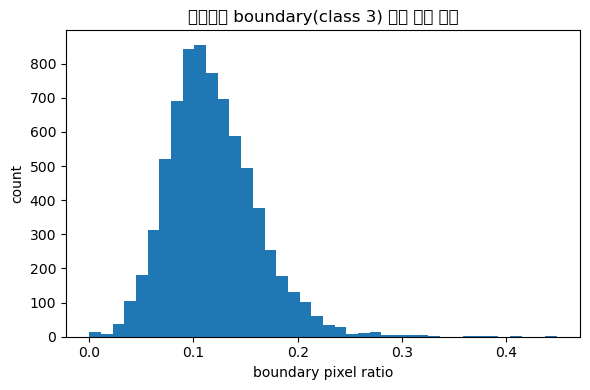

In [5]:
from notebooks.common import plot_histogram

pet_ratios, background_ratios, boundary_ratios = [], [], []
for stem in stems:
    mask_array = np.array(Image.open(os.path.join(TRIMAPS_DIR, stem + ".png")))
    total = mask_array.size
    pet_ratios.append(float((mask_array == 1).sum()) / total)
    background_ratios.append(float((mask_array == 2).sum()) / total)
    boundary_ratios.append(float((mask_array == 3).sum()) / total)

print(f"pet(1) 평균 비율:        {sum(pet_ratios)/len(pet_ratios):.4f}")
print(f"background(2) 평균 비율: {sum(background_ratios)/len(background_ratios):.4f}")
print(f"boundary(3) 평균 비율:   {sum(boundary_ratios)/len(boundary_ratios):.4f}  (항상 소수 -- 객체 경계선이라 픽셀 수 자체가 적다)")

plot_histogram(boundary_ratios, bins=40, title="이미지당 boundary(class 3) 픽셀 비율 분포",
               xlabel="boundary pixel ratio")

### raw 샘플 그리드 -- 이미지와 원본 trimap

/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_

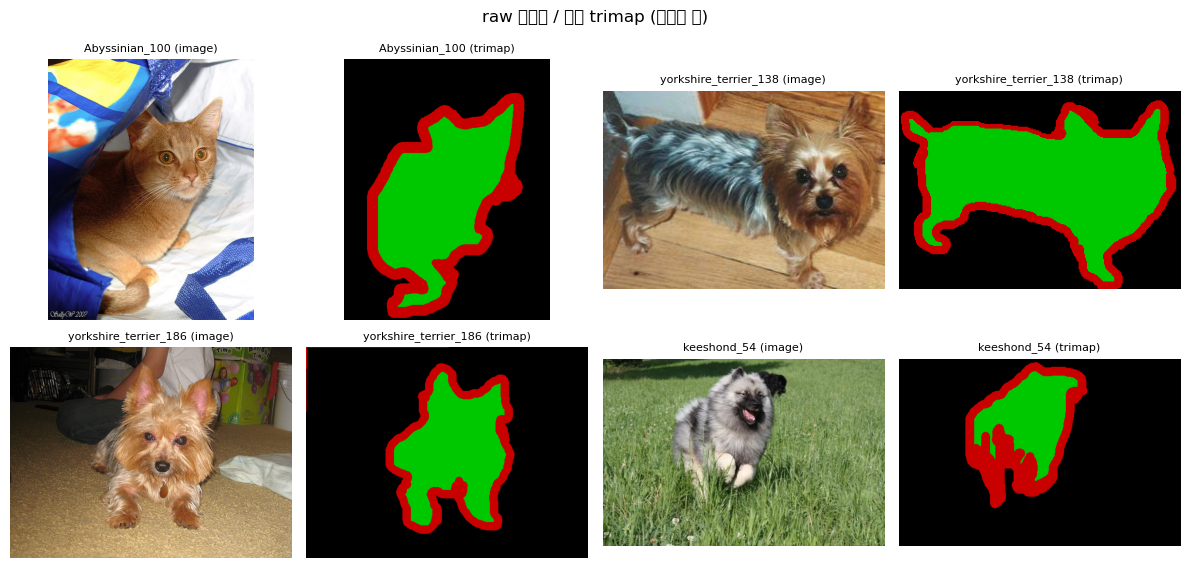

In [6]:
from notebooks.common import show_image_grid

TRIMAP_DISPLAY_COLORS = {1: (0, 200, 0), 2: (0, 0, 0), 3: (200, 0, 0)}  # pet=green, bg=black, boundary=red


def trimap_to_rgb(mask_array):
    rgb = np.zeros((*mask_array.shape, 3), dtype=np.uint8)
    for value, color in TRIMAP_DISPLAY_COLORS.items():
        rgb[mask_array == value] = color
    return rgb


sample_stems = stems[::len(stems) // 4][:4]
grid_images = []
for stem in sample_stems:
    image = Image.open(os.path.join(DATASET_ROOT, "images", stem + ".jpg")).convert("RGB")
    mask_array = np.array(Image.open(os.path.join(TRIMAPS_DIR, stem + ".png")))
    grid_images.append(image)
    grid_images.append(Image.fromarray(trimap_to_rgb(mask_array)))

titles = [t for stem in sample_stems for t in (f"{stem} (image)", f"{stem} (trimap)")]
show_image_grid(grid_images, titles=titles, ncols=4, title="raw 이미지 / 원본 trimap (재매핑 전)")

## 2. Dataset / DataLoader 출력 검증

여기서부터는 v0.1이 학습에 쓴 subset split(`configs/splits/oxford_pets_subset_seg.json`,
296/74/74)을 쓴다.

In [7]:
from src.tasks.segmentation.dataset import TRIMAP_VALUE_TO_CLASS_INDEX, remap_trimap

print("trimap 원본값 -> 프로젝트 클래스 인덱스 매핑:", TRIMAP_VALUE_TO_CLASS_INDEX)
print(inspect.getsource(remap_trimap))

trimap 원본값 -> 프로젝트 클래스 인덱스 매핑: {2: 0, 1: 1, 3: 2}
def remap_trimap(mask_array):
    """Map raw trimap pixel values {1,2,3} to project class indices {1,0,2}. Raises if any
    pixel holds a value outside {1,2,3} instead of silently ignoring it (PLAN-P3 SS3.1)."""
    unexpected = sorted(set(np.unique(mask_array).tolist()) - set(TRIMAP_VALUE_TO_CLASS_INDEX.keys()))
    if unexpected:
        raise RuntimeError(
            f"trimap contains unexpected pixel values {unexpected}; only "
            f"{sorted(TRIMAP_VALUE_TO_CLASS_INDEX.keys())} are valid (PLAN-P3 SS3.1)."
        )
    return TRIMAP_LOOKUP_TABLE[mask_array]



In [8]:
from src.core.registry import DATASETS, TRANSFORMS

raw_valid_ds = DATASETS.build("oxford_pets_seg", root=DATASET_ROOT, split="valid", transform=None,
                               split_path="configs/splits/oxford_pets_subset_seg.json")
print("valid split size:", len(raw_valid_ds))
print("class_names:", raw_valid_ds.classes)

raw_image, raw_mask = raw_valid_ds[0]
print("\ntransform=None -- image:", raw_image.shape, raw_image.dtype)
print("mask:", raw_mask.shape, raw_mask.dtype, "unique values:", torch.unique(raw_mask).tolist(),
      "-- {0,1,2} 범위, {1,2,3} 원본과 다르다 (remap_trimap이 이미 __getitem__ 안에서 적용됨)")

valid split size: 74
class_names: ['background', 'pet', 'boundary']

transform=None -- image: torch.Size([3, 1024, 1536]) torch.float32
mask: torch.Size([1024, 1536]) torch.int64 unique values: [0, 1, 2] -- {0,1,2} 범위, {1,2,3} 원본과 다르다 (remap_trimap이 이미 __getitem__ 안에서 적용됨)


### transform 적용 전후 -- 마스크도 함께 변형되지만 보간 방식이 다르다

`toy/02_toy_seg.ipynb`에서는 toy 마스크가 아예 transform을 타지 않았다. 실데이터는 다르다 --
`SegmentationTransform`은 이미지와 마스크를 **함께** `RandomResizedCrop`/`Resize`에 통과시켜야
같은 영역을 잘라내지만(안 그러면 이미지와 마스크가 어긋난다), 보간 방식은 다르게 선택된다: 이미지는
연속값이라 `bilinear`가 자연스럽지만 마스크는 클래스 인덱스이므로 `nearest`만 허용된다. torchvision
`v2` transform은 `tv_tensors.Mask`로 감싸진 텐서를 자동으로 `nearest`로 보간한다.

In [9]:
from src.tasks.segmentation.transform import SegmentationTransform

print(inspect.getsource(SegmentationTransform.__call__))
print(inspect.getsource(TRANSFORMS.get("seg_eval")))

    def __call__(self, image, target=None):
        image = tv_tensors.Image(image) if not isinstance(image, tv_tensors.Image) else image
        if target is None:
            # Predict path (src/cli/commands.py) has no mask. Feed a same-size dummy mask
            # through the joint compose so RandomResizedCrop/Resize compute identical crop/
            # resize parameters as they would with a real mask, then discard it.
            height, width = image.shape[-2], image.shape[-1]
            dummy_mask = tv_tensors.Mask(torch.zeros(1, height, width, dtype=torch.int64))
            transformed_image, _ = self.compose(image, dummy_mask)
            return transformed_image

        mask = tv_tensors.Mask(target) if not isinstance(target, tv_tensors.Mask) else target
        transformed_image, transformed_mask = self.compose(image, mask)
        return transformed_image, transformed_mask.to(torch.int64)

@TRANSFORMS.register("seg_eval")
def build_seg_eval_transform(image_size, train=F

`{name}.__call__`이 마스크를 `tv_tensors.Mask`로 감싸는 것만으로는 nearest 보간이 실제로
적용되는지 증명되지 않는다 (원본 마스크 값이 우연히 보간 후에도 정수로 남을 수도 있으므로). 작은
합성 마스크로 직접 검증한다: 같은 downscale을 nearest와 bilinear 두 방식으로 각각 적용해, nearest만
입력에 없던 새 값(예: 0.5)을 만들지 않는다는 것을 확인한다.

In [10]:
import torch.nn.functional as Fnn
from torchvision import tv_tensors
from torchvision.transforms import v2

# checkerboard-like synthetic mask with values {0, 1, 2} only.
synthetic_mask = torch.zeros(1, 8, 8, dtype=torch.int64)
synthetic_mask[:, :4, :4] = 1
synthetic_mask[:, 4:, 4:] = 2

nearest_resized = v2.functional.resize(tv_tensors.Mask(synthetic_mask), size=[5, 5])
bilinear_resized = Fnn.interpolate(synthetic_mask.float().unsqueeze(0), size=(5, 5), mode="bilinear",
                                    align_corners=False).squeeze(0)

print("nearest 결과 고유값 (원본 {0,1,2} 안에만 있어야 한다):", torch.unique(nearest_resized).tolist())
print("bilinear 결과 고유값 (원본에 없던 중간값이 섞인다):",
      sorted(set(round(v, 2) for v in bilinear_resized.flatten().tolist())))
assert set(torch.unique(nearest_resized).tolist()) <= {0, 1, 2}, "nearest는 새 값을 만들면 안 된다"
print("\n-> v2.functional.resize가 tv_tensors.Mask를 자동으로 nearest 보간한다는 것을 확인했다.")

nearest 결과 고유값 (원본 {0,1,2} 안에만 있어야 한다): [0, 1, 2]
bilinear 결과 고유값 (원본에 없던 중간값이 섞인다): [0.0, 0.5, 0.75, 1.0, 2.0]

-> v2.functional.resize가 tv_tensors.Mask를 자동으로 nearest 보간한다는 것을 확인했다.


transform 적용 후 -- image: torch.Size([3, 256, 256]) torch.float32
mask: torch.Size([256, 256]) torch.int64 unique values: [0, 1, 2]
mask 값이 여전히 {0,1,2} 범위 -- nearest 보간이라 존재하지 않는 값(예: 0.5)이 생기지 않는다


/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/2608

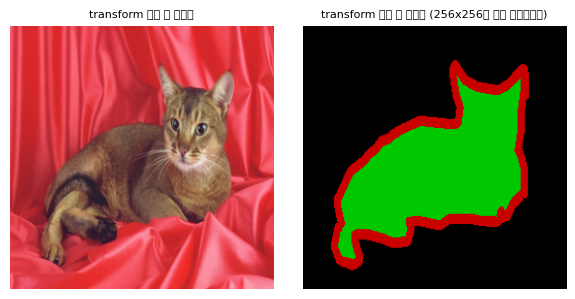

In [11]:
transform_eval = TRANSFORMS.build("seg_eval", (256, 256), False)
transformed_ds = DATASETS.build("oxford_pets_seg", root=DATASET_ROOT, split="valid",
                                 transform=transform_eval,
                                 split_path="configs/splits/oxford_pets_subset_seg.json")
t_image, t_mask = transformed_ds[0]
print("transform 적용 후 -- image:", t_image.shape, t_image.dtype)
print("mask:", t_mask.shape, t_mask.dtype, "unique values:", torch.unique(t_mask).tolist())
print("mask 값이 여전히 {0,1,2} 범위 -- nearest 보간이라 존재하지 않는 값(예: 0.5)이 생기지 않는다")

from src.tasks.segmentation.visualize import mask_to_rgb, tensor_to_pil
from notebooks.common import show_image_grid

show_image_grid([tensor_to_pil(t_image), Image.fromarray(mask_to_rgb(t_mask))],
                 titles=["transform 적용 후 이미지", "transform 적용 후 마스크 (256x256로 함께 리사이즈됨)"],
                 ncols=2)

### `collate_fn` 통과 후 배치 구조

마스크가 transform 이후 고정 `(256, 256)`이므로 (`toy/02_toy_seg.ipynb`와 같은 이유로) 기본
`default_collate`로 충분하다.

In [12]:
from src.core.registry import ADAPTERS, LOSSES, METRICS
from src.cli.commands import bind_class_names
from torch.utils.data import DataLoader

loss_fn = LOSSES.build("seg_cross_entropy", ignore_index=-100)
metrics = {"miou": METRICS.build("miou", num_classes=3), "dice": METRICS.build("dice", num_classes=3)}
adapter = ADAPTERS.build("segmentation", loss_fn, metrics)
bind_class_names(adapter, transformed_ds)
print("adapter.collate_fn():", adapter.collate_fn())

loader = DataLoader(transformed_ds, batch_size=8, shuffle=False, collate_fn=adapter.collate_fn())
batch_images, batch_masks = next(iter(loader))
print("batch images:", batch_images.shape)
print("batch masks: ", batch_masks.shape, batch_masks.dtype)

adapter.collate_fn(): None
batch images: torch.Size([8, 3, 256, 256])
batch masks:  torch.Size([8, 256, 256]) torch.int64


## 3. 모델별 섹션

`custom_unet` -> `deeplabv3_resnet50` -> `fcn_resnet50` 순서. `deeplabv3`는 ASPP(다중 팽창률
conv) head를, `fcn`은 단순 conv head를 쓴다는 점이 두 pretrained 모델의 유일한 구조 차이이며,
5장 비교에서 이것이 성능에 어떤 영향을 주는지 본다.

In [13]:
from notebooks.common import FeatureMapRecorder, plot_training_curves, show_feature_maps, show_predictions
from src.core.checkpoint import load_checkpoint
from src.core.registry import MODELS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_batch = next(iter(DataLoader(transformed_ds, batch_size=4, shuffle=False,
                                     collate_fn=adapter.collate_fn())))


def load_model_for_split(model_name, split_name, **model_params):
    model = MODELS.build(model_name, num_classes=3, **model_params)
    checkpoint_path = os.path.join(BENCH_DIR, "splits", split_name, "checkpoints", "best.pth")
    load_checkpoint(checkpoint_path, model, map_location="cpu", restore_rng=False)
    model.to(DEVICE)
    model.eval()
    return model

### 3.1 `custom_unet` -- from-scratch encoder-decoder

`src/tasks/segmentation/models/custom_unet.py`: 5-stage encoder(각 stage stride=2)와 대칭
decoder가 skip connection으로 이어진다. `Conv2d(kernel=3, stride=2, padding=1)`은 홀수 크기를
`ceil(H/2)`로 올림 처리하므로, decoder가 5단계 업샘플을 거쳐도 입력 해상도가 32의 배수가 아니면
정확히 되돌아오지 않는다 -- 마지막에 입력 해상도로 다시 bilinear 보간해 정렬한다.

In [14]:
print(inspect.getsource(MODELS.get("custom_unet_seg")))

@MODELS.register("custom_unet_seg")
class CustomUnet(nn.Module):
    def __init__(self, num_classes=3, backbone_name=None, weights_path=None, **params):
        super().__init__()
        # backbone_name and weights_path are unused for this from-scratch model;
        # kept only for interface uniformity with the other segmentation models.
        self.encoder = CustomUnetEncoder()
        self.decoder = CustomUnetDecoder()
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, images):
        encoder_features = self.encoder(images)
        decoder_output = self.decoder(encoder_features)
        logits = self.head(decoder_output)
        # Stride-2 encoder stages round non-multiple-of-32 spatial sizes upward; realign
        # logits to the exact input resolution (PLAN-P3 SS4.1).
        if logits.shape[-2:] != images.shape[-2:]:
            logits = nn.functional.interpolate(
                logits, size=images.shape[-2:], mode="bilinear", align_corners=

In [15]:
unet_model = load_model_for_split("custom_unet_seg", "custom_unet")

with torch.no_grad():
    x = sample_batch[0].to(DEVICE)
    encoder_features = unet_model.encoder(x)
    for i, feat in enumerate(encoder_features, start=1):
        print(f"encoder c{i}: {tuple(feat.shape)}")
    decoder_out = unet_model.decoder(encoder_features)
    print("decoder output:", tuple(decoder_out.shape))
    logits = unet_model(x)
    print("logits (입력 해상도로 재정렬됨):", tuple(logits.shape), " input:", tuple(x.shape))

encoder c1: (4, 32, 128, 128)
encoder c2: (4, 64, 64, 64)
encoder c3: (4, 128, 32, 32)
encoder c4: (4, 256, 16, 16)
encoder c5: (4, 512, 8, 8)
decoder output: (4, 32, 256, 256)
logits (입력 해상도로 재정렬됨): (4, 3, 256, 256)  input: (4, 3, 256, 256)


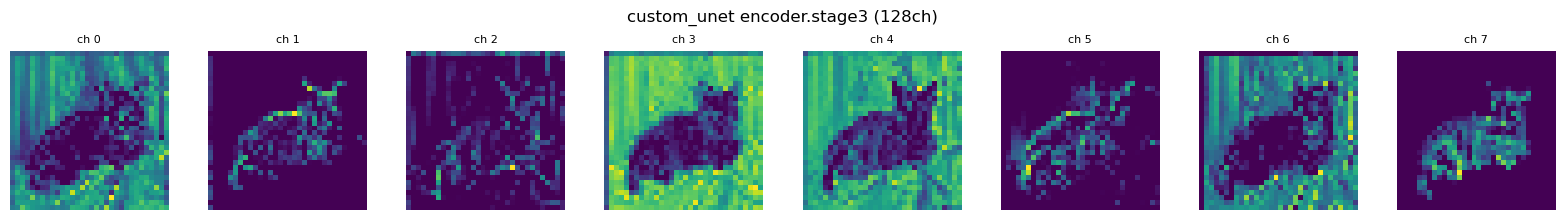

In [16]:
with FeatureMapRecorder(unet_model, "encoder.stage3") as recorder:
    with torch.no_grad():
        unet_model(sample_batch[0].to(DEVICE))
show_feature_maps(recorder.output, num_channels=8, title="custom_unet encoder.stage3 (128ch)")

/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/nampl/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

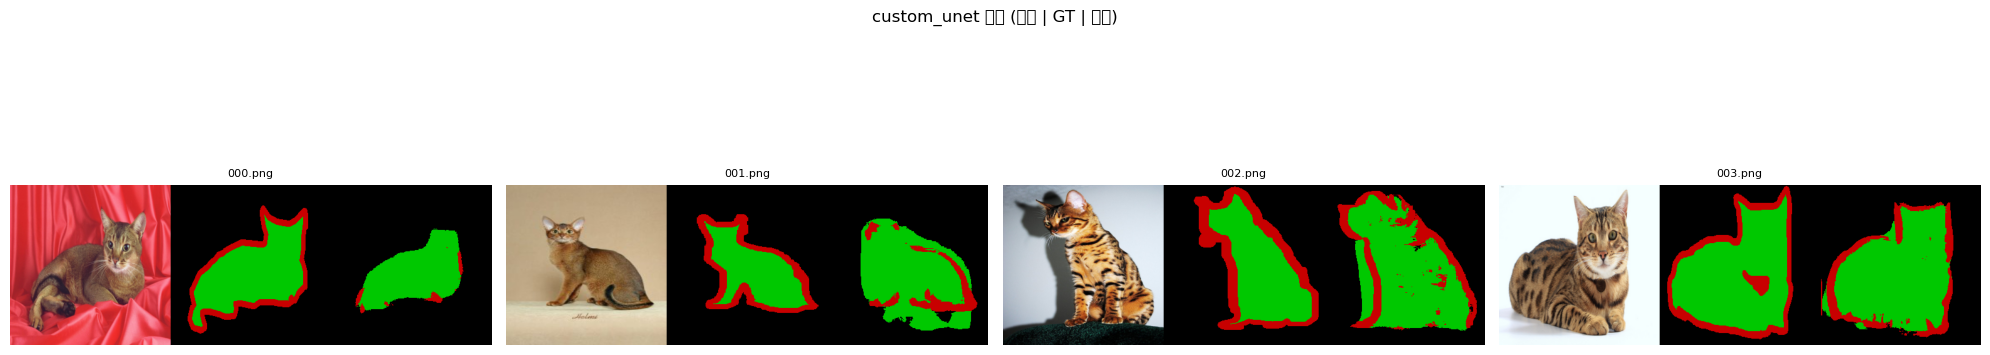

In [17]:
with torch.no_grad():
    unet_predictions = adapter.predict_step(unet_model, sample_batch, DEVICE)
show_predictions(adapter, sample_batch, unet_predictions, max_items=4, title="custom_unet 예측 (원본 | GT | 예측)")

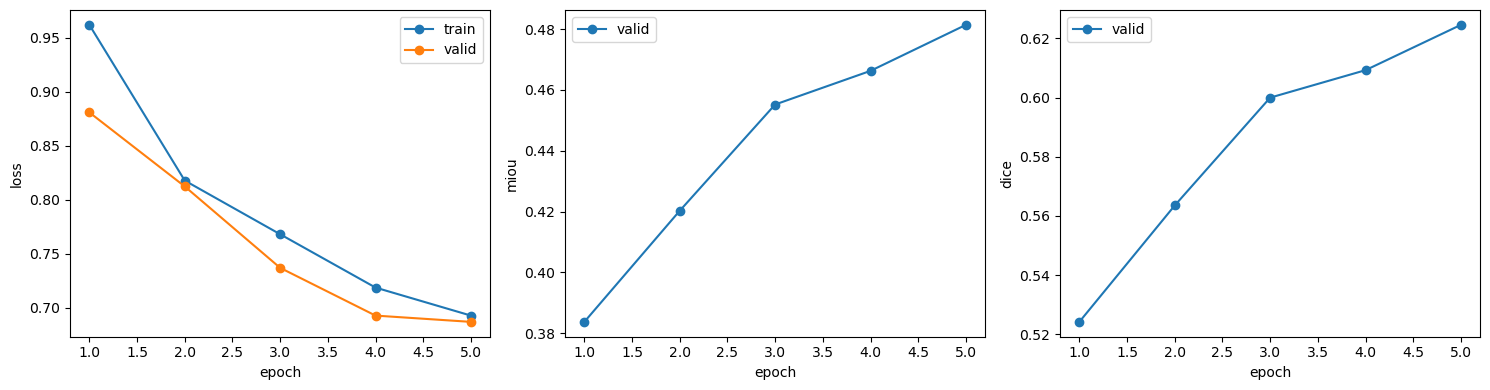

,epoch,split,loss,miou,dice,lr,elapsed_sec
44,1,train,0.961928,NaN,NaN,0.000300,2.141793
45,1,valid,0.880896,0.383720,0.524200,0.000000,0.722030
46,2,train,0.817808,NaN,NaN,0.000271,1.647978
47,2,valid,0.812387,0.420270,0.563547,0.000000,0.523604
48,3,train,0.768135,NaN,NaN,0.000197,1.612664
49,3,valid,0.737036,0.455221,0.599991,0.000000,0.480710
50,4,train,0.718775,NaN,NaN,0.000104,1.614457
51,4,valid,0.692853,0.466291,0.609282,0.000000,0.486765
52,5,train,0.692848,NaN,NaN,0.000030,1.620953
53,5,valid,0.687036,0.481423,0.624601,0.000000,0.506459


In [18]:
plot_training_curves(os.path.join(BENCH_DIR, "splits", "custom_unet", "metrics_epoch.csv"),
                      ["miou", "dice"])

### 3.2 `deeplabv3_resnet50` -- ASPP head, COCO pretrained

`src/tasks/segmentation/models/deeplabv3_resnet50.py`: torchvision `deeplabv3_resnet50`에 로컬
COCO 체크포인트를 21-class 헤드 상태로 `strict=True` 주입한 뒤, 마지막 classifier conv만
3-class로 교체한다. DeepLabV3의 classifier는 ASPP(Atrous Spatial Pyramid Pooling) 모듈을
포함한다 -- 여러 팽창률(dilation)의 conv를 병렬로 적용해 다양한 receptive field를 동시에 본다.

In [19]:
print(inspect.getsource(MODELS.get("deeplabv3_resnet50_seg")))

@MODELS.register("deeplabv3_resnet50_seg")
class DeepLabV3ResNet50Segmenter(nn.Module):
    def __init__(self, num_classes=3, backbone_name="resnet50", weights_path=None, **params):
        super().__init__()
        # aux_loss=True and num_classes=21 are required at construction time so the
        # module's state_dict keys (including aux_classifier.*) match the local COCO
        # checkpoint exactly, enabling strict=True loading below.
        self.model = tvm_seg.deeplabv3_resnet50(
            weights=None, weights_backbone=None, num_classes=21, aux_loss=True
        )
        # Load the local COCO checkpoint while the head is still the original
        # 21-class head, so strict=True key matching succeeds. weights_path is
        # never None-checked here: load_local_weights raises LocalAssetError
        # for a missing/None path instead of silently random-initializing.
        load_local_weights(self.model, weights_path, strict=True)

        # Replace the final classifier con

In [20]:
deeplab_model = load_model_for_split("deeplabv3_resnet50_seg", "deeplabv3_resnet50",
                                      backbone_name="resnet50",
                                      weights_path="/mnt/d/backbones/deeplabv3_resnet50_coco-cd0a2569.pth")

print("classifier 구조 (ASPP 포함):")
print(deeplab_model.model.classifier)

with torch.no_grad():
    x = sample_batch[0].to(DEVICE)
    backbone_out = deeplab_model.model.backbone(x)
    print("\nbackbone output keys:", list(backbone_out.keys()))
    print("backbone 'out':", tuple(backbone_out["out"].shape))
    logits = deeplab_model(x)
    print("logits:", tuple(logits.shape), " input:", tuple(x.shape))

classifier 구조 (ASPP 포함):
DeepLabHead(
  (0): ASPP(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(12, 12), dilation=(12, 12), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(24, 24), dilation=(24, 24), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(36, 36), dilation=(36, 36), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum

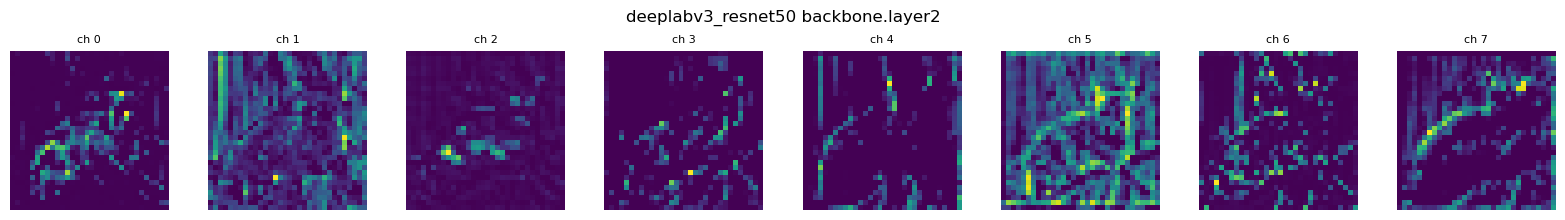

In [21]:
with FeatureMapRecorder(deeplab_model, "model.backbone.layer2") as recorder:
    with torch.no_grad():
        deeplab_model(sample_batch[0].to(DEVICE))
show_feature_maps(recorder.output, num_channels=8, title="deeplabv3_resnet50 backbone.layer2")

/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/nampl/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

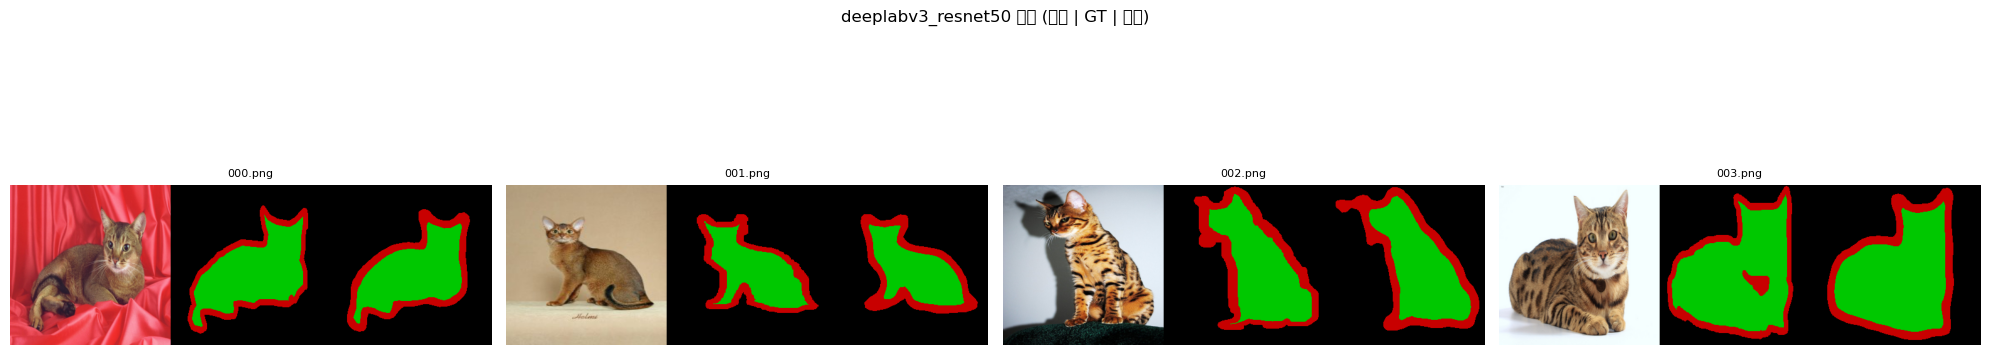

In [22]:
with torch.no_grad():
    deeplab_predictions = adapter.predict_step(deeplab_model, sample_batch, DEVICE)
show_predictions(adapter, sample_batch, deeplab_predictions, max_items=4,
                  title="deeplabv3_resnet50 예측 (원본 | GT | 예측)")

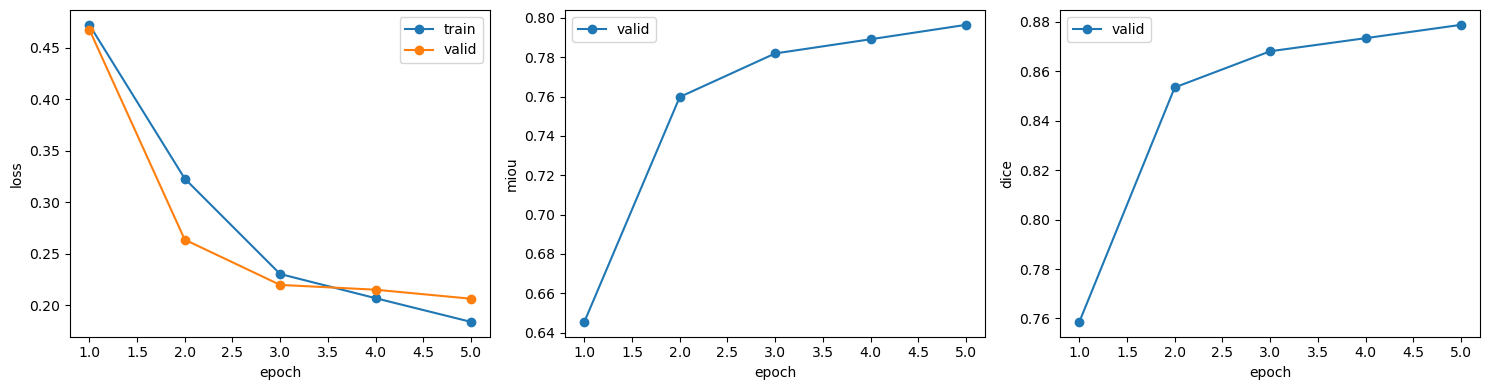

,epoch,split,loss,miou,dice,lr,elapsed_sec
44,1,train,0.472443,NaN,NaN,0.000300,23.871480
45,1,valid,0.467845,0.645406,0.758631,0.000000,1.524739
46,2,train,0.323112,NaN,NaN,0.000271,23.740136
47,2,valid,0.263819,0.759771,0.853461,0.000000,1.355582
48,3,train,0.230466,NaN,NaN,0.000197,23.507260
49,3,valid,0.219902,0.781919,0.868082,0.000000,1.365934
50,4,train,0.206997,NaN,NaN,0.000104,23.729615
51,4,valid,0.215216,0.789128,0.873379,0.000000,1.357961
52,5,train,0.183983,NaN,NaN,0.000030,23.548998
53,5,valid,0.206472,0.796459,0.878767,0.000000,1.369832


In [23]:
plot_training_curves(
    os.path.join(BENCH_DIR, "splits", "deeplabv3_resnet50", "metrics_epoch.csv"), ["miou", "dice"])

### 3.3 `fcn_resnet50` -- 단순 head, COCO pretrained

`src/tasks/segmentation/models/fcn_resnet50.py`: 같은 ResNet50 backbone에 ASPP 없이 conv 2개로
구성된 단순한 FCN head를 쓴다. backbone과 사전학습 체크포인트 출처(COCO)는 `deeplabv3`와 동일하고,
head 구조만 다르다 -- 이 노트북에서 통제되는 유일한 아키텍처 변수다.

In [24]:
print(inspect.getsource(MODELS.get("fcn_resnet50_seg")))

@MODELS.register("fcn_resnet50_seg")
class FCNResNet50Segmenter(nn.Module):
    def __init__(self, num_classes=3, backbone_name="resnet50", weights_path=None, **params):
        super().__init__()
        # aux_loss=True and num_classes=21 are required at construction time so the
        # module's state_dict keys (including aux_classifier.*) match the local COCO
        # checkpoint exactly, enabling strict=True loading below.
        self.model = tvm_seg.fcn_resnet50(
            weights=None, weights_backbone=None, num_classes=21, aux_loss=True
        )
        # Load the local COCO checkpoint while the head is still the original
        # 21-class head, so strict=True key matching succeeds. weights_path is
        # never None-checked here: load_local_weights raises LocalAssetError
        # for a missing/None path instead of silently random-initializing.
        load_local_weights(self.model, weights_path, strict=True)

        # Replace the final classifier conv with a num_class

In [25]:
fcn_model = load_model_for_split("fcn_resnet50_seg", "fcn_resnet50", backbone_name="resnet50",
                                  weights_path="/mnt/d/backbones/fcn_resnet50_coco-1167a1af.pth")

print("classifier 구조 (ASPP 없음, deeplabv3보다 단순):")
print(fcn_model.model.classifier)

with torch.no_grad():
    x = sample_batch[0].to(DEVICE)
    logits = fcn_model(x)
    print("\nlogits:", tuple(logits.shape), " input:", tuple(x.shape))

classifier 구조 (ASPP 없음, deeplabv3보다 단순):
FCNHead(
  (0): Conv2d(2048, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Conv2d(512, 3, kernel_size=(1, 1), stride=(1, 1))
)

logits: (4, 3, 256, 256)  input: (4, 3, 256, 256)


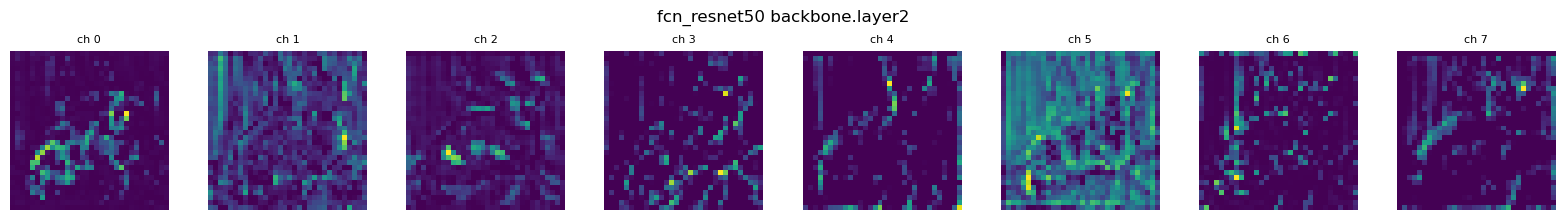

In [26]:
with FeatureMapRecorder(fcn_model, "model.backbone.layer2") as recorder:
    with torch.no_grad():
        fcn_model(sample_batch[0].to(DEVICE))
show_feature_maps(recorder.output, num_channels=8, title="fcn_resnet50 backbone.layer2")

/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/nampl/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

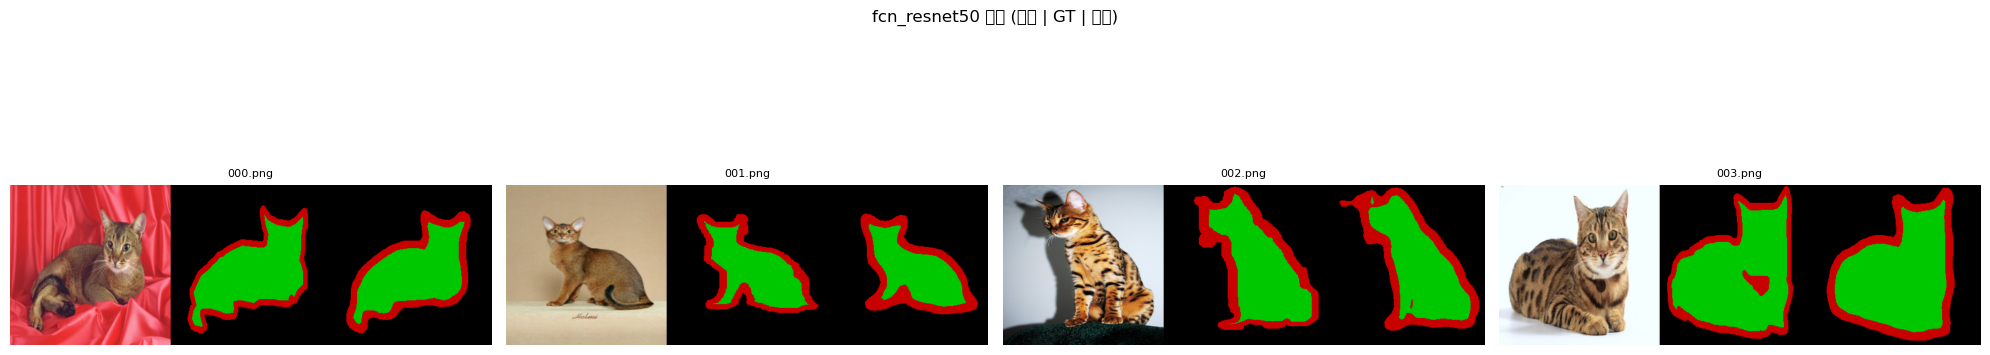

In [27]:
with torch.no_grad():
    fcn_predictions = adapter.predict_step(fcn_model, sample_batch, DEVICE)
show_predictions(adapter, sample_batch, fcn_predictions, max_items=4,
                  title="fcn_resnet50 예측 (원본 | GT | 예측)")

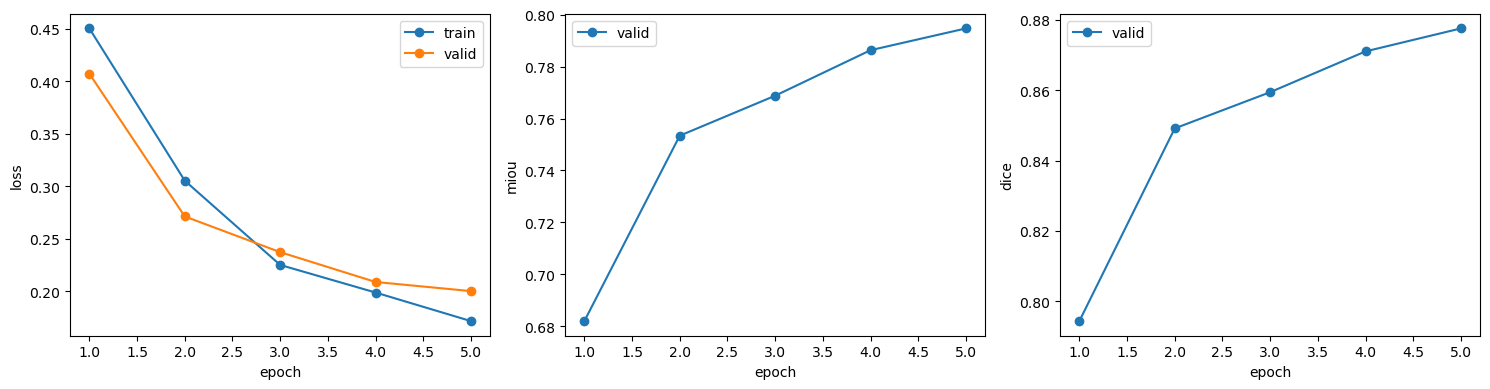

,epoch,split,loss,miou,dice,lr,elapsed_sec
44,1,train,0.450293,NaN,NaN,0.000300,13.187098
45,1,valid,0.407177,0.682065,0.794438,0.000000,1.234461
46,2,train,0.305221,NaN,NaN,0.000271,13.199581
47,2,valid,0.271127,0.753391,0.849126,0.000000,1.106875
48,3,train,0.224908,NaN,NaN,0.000197,13.540181
49,3,valid,0.237099,0.768768,0.859406,0.000000,1.132154
50,4,train,0.198618,NaN,NaN,0.000104,13.128343
51,4,valid,0.208666,0.786278,0.870986,0.000000,1.111980
52,5,train,0.171395,NaN,NaN,0.000030,13.168006
53,5,valid,0.199967,0.794659,0.877506,0.000000,1.121938


In [28]:
plot_training_curves(os.path.join(BENCH_DIR, "splits", "fcn_resnet50", "metrics_epoch.csv"),
                      ["miou", "dice"])

## 4. 3모델 비교

In [29]:
from notebooks.common import load_leaderboard, plot_tradeoff

leaderboard = load_leaderboard(os.path.join(BENCH_DIR, "leaderboard.csv"))
leaderboard[["split", "miou", "dice", "params_total", "flops_g", "fps"]]

,split,miou,dice,params_total,flops_g,fps
0,deeplabv3_resnet50,0.793815,0.876927,39634243,81.781064,46.131181
1,fcn_resnet50,0.792626,0.876027,32947779,69.165122,61.762490
2,custom_unet,0.470088,0.616811,3929987,5.476712,437.708594


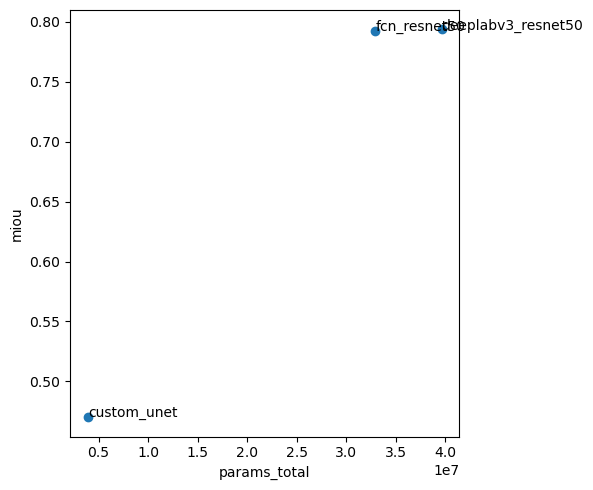

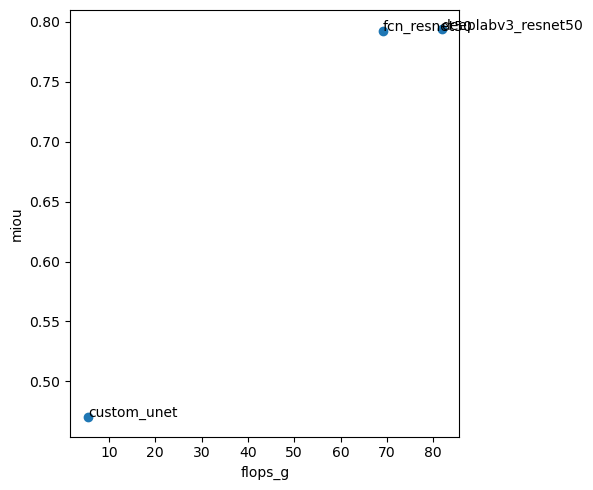

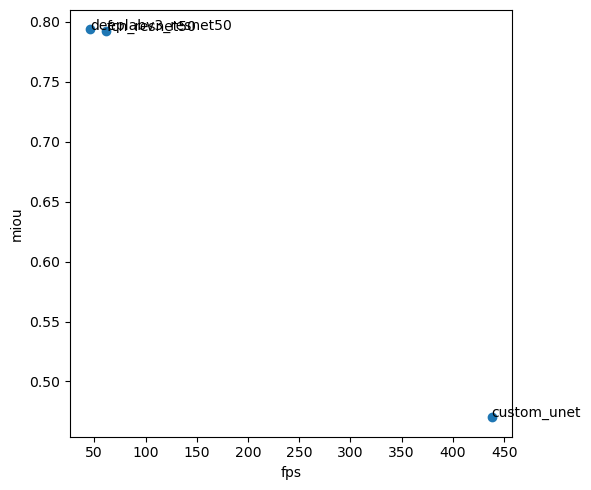

In [30]:
plot_tradeoff(leaderboard, "miou", "params_total", label_column="split")
plot_tradeoff(leaderboard, "miou", "flops_g", label_column="split")
plot_tradeoff(leaderboard, "miou", "fps", label_column="split")

`deeplabv3_resnet50`과 `fcn_resnet50`은 mIoU가 소폭 다르다. 두 모델은 backbone 구조(ResNet50)와
head 설계(ASPP 유무)가 유일한 명시적 아키텍처 차이지만, 각자 서로 다른 COCO pretrained 체크포인트
파일(`deeplabv3_resnet50_coco-*.pth` / `fcn_resnet50_coco-*.pth`)에서 backbone 가중치를 읽어오므로
**backbone의 초기 파라미터 값까지 완전히 동일하다고 통제되지는 않았다** -- 관측된 차이를 head 설계
효과로만 단정할 수는 없고, 사전학습 체크포인트 차이가 섞여 있을 가능성을 열어둬야 한다.
`custom_unet`은 from-scratch라 5 epoch만으로는 두 pretrained 모델에 크게 못 미친다.

### 통제 조건 확인 -- 실제 `control_report.json` 재사용

`01_classification.ipynb`와 동일한 방식이다: 손으로 필드를 고르지 않고, v0.1이 벤치마크 실행
시점에 `enforce_control()`로 이미 검증해 저장한 결과를 그대로 불러온다.

In [31]:
from src.bench.control import CONTROL_FIELDS
from src.utils.io import load_json, load_yaml

control_report = load_json(os.path.join(BENCH_DIR, "control_report.json"))
print(f"통제 대상 필드 {len(CONTROL_FIELDS)}개 (model.* 제외)")
print("violations (비어 있어야 한다):", control_report["violations"])
assert not control_report["violations"], "통제 필드에 미승인 차이가 있으면 안 된다"

resolved = {split_name: load_yaml(os.path.join(BENCH_DIR, "splits", split_name, "config.resolved.yaml"))
            for split_name in MODEL_SPLITS}
print("\nmodel 섹션 (통제 대상이 아니다):")
for split_name, cfg in resolved.items():
    print(f"  {split_name}: {cfg['model']}")

통제 대상 필드 22개 (model.* 제외)
violations (비어 있어야 한다): []

model 섹션 (통제 대상이 아니다):
  custom_unet: {'name': 'custom_unet_seg', 'params': {'num_classes': 3}}
  deeplabv3_resnet50: {'name': 'deeplabv3_resnet50_seg', 'params': {'num_classes': 3, 'backbone_name': 'resnet50', 'weights_path': '/mnt/d/backbones/deeplabv3_resnet50_coco-cd0a2569.pth'}}
  fcn_resnet50: {'name': 'fcn_resnet50_seg', 'params': {'num_classes': 3, 'backbone_name': 'resnet50', 'weights_path': '/mnt/d/backbones/fcn_resnet50_coco-1167a1af.pth'}}


## 요약

- Segmentation의 target은 `(H, W)` long 마스크이며, 원본 trimap 값 `{1,2,3}`을 프로젝트 클래스
  `{1,0,2}`(pet/background/boundary)로 재매핑한 것이다 (`remap_trimap`).
- boundary(class 2) 픽셀 비율은 이미지마다 소수다 -- 객체 경계선이라는 성질 자체가 EDA 히스토그램에
  그대로 드러난다.
- transform은 이미지·마스크를 함께(같은 crop/resize 파라미터로) 변형하되, 보간 방식은 이미지=bilinear,
  마스크=nearest로 다르다 -- `toy_seg`처럼 마스크가 transform을 아예 건너뛰는 것과는 다른 방식으로
  같은 원칙(클래스 인덱스에 보간을 적용하지 않는다)을 지킨다.
- 세 모델은 동일 통제 조건에서 학습됐고, `deeplabv3_resnet50`/`fcn_resnet50`은 backbone과 pretrained
  출처가 같아 ASPP head 유무만 성능 차이의 아키텍처 변수로 볼 수 있다.

다음(`03_detection.ipynb`)은 target이 다시 가변 길이(박스 개수)로 바뀌는 경우를 실데이터로 본다.